<div class='bar_title'></div>

*Simulation for Decision Making (S4DM)*

# Exercise 4 — Generating Input Data (Solution)

Summer Semester 26

Gunther Gust & Govind Rao <br>
Chair for Enterprise AI <br>
Data Driven Decisions Group <br>
Center for Artificial Intelligence and Data Science (CAIDAS)

<img src="images/d3.png" style="width:20%; float:left;" />

<img src="images/CAIDASlogo.png" style="width:20%; float:left;" />

## Overview

In this exercise you generate random input data for simulations from scratch — both for **uniform pseudo-random numbers** and for **arbitrary target distributions**. You will:

| Part | Topic |
|---|---|
| **A** | Pseudo-random numbers and the LCG |
| **B** | The inverse-transform method |
| **C** | Convolution — Erlang from Exponentials |
| **D** | Acceptance-Rejection sampling |
| **E** | Common Random Numbers (CRN) for fair comparison |
| **Short Questions** | Exam-comparable practice |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import simpy
from scipy import stats

---
## Part A — Pseudo-random numbers and the LCG

Every NumPy random call ultimately rests on a deterministic algorithm controlled by a **seed**. In this part you'll see how reproducibility works, build a simple Linear Congruential Generator (LCG), and learn to spot a bad one visually.

### Task A.1 — Reproducibility check

Create two `np.random.default_rng()` instances with the **same** seed and one with a **different** seed. Draw 5 uniform samples from each. Confirm:

1. The two same-seed generators produce identical sequences.
2. The differently-seeded generator produces a different sequence.

In [2]:
# SOLUTION
rng_a = np.random.default_rng(seed=42)
rng_b = np.random.default_rng(seed=42)   # same seed
rng_c = np.random.default_rng(seed=99)   # different seed

print('rng_a:', rng_a.random(5))
print('rng_b:', rng_b.random(5))
print('rng_c:', rng_c.random(5))

# rng_a and rng_b produce IDENTICAL sequences — same seed → same deterministic stream.
# rng_c is unrelated.

rng_a: [0.77395605 0.43887844 0.85859792 0.69736803 0.09417735]
rng_b: [0.77395605 0.43887844 0.85859792 0.69736803 0.09417735]
rng_c: [0.50603067 0.56509163 0.51191596 0.97218637 0.61490314]


### Task A.2 — Implement an LCG and find its period

Complete the function `lcg(seed, a, c, m, n)` that generates `n` samples using the recurrence $X_{n+1} = (a \cdot X_n + c) \bmod m$.

Then run it on the following two parameter sets and report the **period** of each.

| Set | $a$ | $c$ | $m$ | Seed |
|---|---|---|---|---|
| 1 | 5 | 3 | 16 | 7 |
| 2 | 4 | 0 | 16 | 1 |

In [3]:
# SOLUTION
def lcg(seed, a, c, m, n):
    x = seed
    out = []
    for _ in range(n):
        x = (a * x + c) % m
        out.append(x)
    return out

def find_period(seq):
    seen = {}
    for i, v in enumerate(seq):
        if v in seen:
            return i - seen[v]
        seen[v] = i
    return None

for label, (a, c, m, s) in [('Set 1', (5, 3, 16, 7)), ('Set 2', (4, 0, 16, 1))]:
    seq = lcg(s, a, c, m, 50)
    print(f'{label}: a={a}, c={c}, m={m}, seed={s} → period = {find_period(seq)}')

# Set 1 has full period (16). Set 2 collapses to 0 quickly — c=0 with even multiplier
# violates the Hull-Dobell conditions.

Set 1: a=5, c=3, m=16, seed=7 → period = 16
Set 2: a=4, c=0, m=16, seed=1 → period = 1


### Task A.3 — Detect a bad LCG visually

For each parameter set above, generate **400 samples** with the LCG, normalize to $[0, 1)$ by dividing by $m$, and plot the consecutive pairs $(X_n, X_{n+1})$ as a scatter on the unit square. What do you observe?

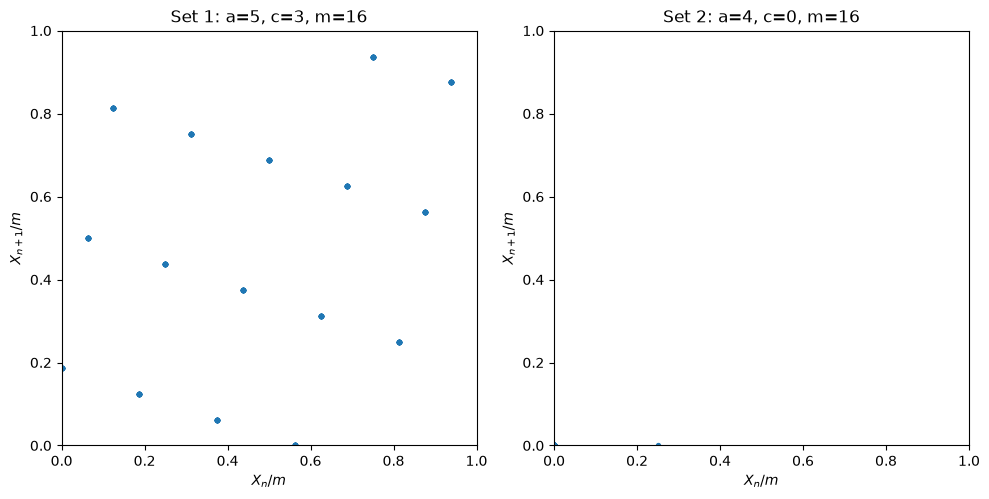

In [4]:
# SOLUTION
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (params, title) in zip(axes, [
        ((5, 3, 16, 7), 'Set 1: a=5, c=3, m=16'),
        ((4, 0, 16, 1), 'Set 2: a=4, c=0, m=16'),
]):
    a, c, m, s = params
    vals = np.array(lcg(s, a, c, m, 400)) / m
    ax.scatter(vals[:-1], vals[1:], s=8, color='#1f77b4')
    ax.set_title(title); ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
    ax.set_xlabel('$X_n / m$'); ax.set_ylabel('$X_{n+1} / m$')
plt.tight_layout(); plt.show()


**How would you describe a good LCG based on what you see?**

**Answer:** A good LCG produces samples that:

- **fill the unit square uniformly** in the consecutive-pair plot — no clustering, no visible structure;
- have a **long period** so the sequence does not repeat within any reasonable simulation length;
- pass statistical tests for **uniformity** and **independence**.

Set 1 (a=5, c=3, m=16) cycles through the full 16 values and spreads them across the square. Set 2 (a=4, c=0, m=16) collapses to the origin within a few steps — c=0 violates the Hull-Dobell condition $\gcd(c, m) = 1$, so the sequence cannot be full-period.

### Task A.4 — Verify the Hull-Dobell conditions (pen and paper)

The lecture appendix states that an LCG $X_{n+1} = (a \cdot X_n + c) \bmod m$ has **full period** $m$ if and only if **all three** of the following hold:

1. $\gcd(c, m) = 1$ — *the increment $c$ and the modulus $m$ share no common divisor other than 1.*
2. For every prime $q$ that divides $m$: $q$ divides $(a - 1)$ — *every prime factor of $m$ also divides $a - 1$.*
3. If $4 \mid m$, then $4 \mid (a - 1)$ — *if 4 divides $m$, then 4 must also divide $a - 1$.*

Apply these conditions **by hand** to the two parameter sets from A.2:

| Set | $a$ | $c$ | $m$ |
|---|---|---|---|
| 1 | 5 | 3 | 16 |
| 2 | 4 | 0 | 16 |

For each set, check each condition and conclude whether the LCG has full period. Do your conclusions match the periods you observed empirically in A.2?

**Verification (pen and paper)**

**Set 1: $a = 5$, $c = 3$, $m = 16$**

1. $\gcd(3, 16) = 1$ ✓
2. Primes dividing $16$: only $2$. Does $2 \mid (a - 1) = 4$? Yes ✓
3. $4 \mid 16$. Does $4 \mid (a - 1) = 4$? Yes ✓

**All three conditions hold → full period $= 16$.** Matches the empirical period from A.2.

---

**Set 2: $a = 4$, $c = 0$, $m = 16$**

1. $\gcd(0, 16) = 16 \neq 1$ ✗ (fails immediately)
2. Primes dividing $16$: only $2$. Does $2 \mid (a - 1) = 3$? No ✗
3. $4 \mid 16$. Does $4 \mid (a - 1) = 3$? No ✗

**All three conditions fail → not full period.** Matches the empirical observation from A.2: the sequence collapses to 0 within a few steps.

---

**Take-away.** Hull-Dobell explains *why* Set 1 worked and Set 2 failed. The empirical observation in A.2 and the theoretical conditions in A.4 give the same answer — as they should.

---
## Part B — Inverse-transform method

The inverse-transform method turns a uniform sample $U \sim \text{Uniform}(0, 1)$ into a sample $X = F^{-1}(U)$ from any distribution with an invertible CDF $F$.

### Task B.0 — Warmup: Uniform $(a, b)$

**(a)** Derive the inverse-transform formula $X = F^{-1}(U)$ for the Uniform $(a, b)$ distribution by hand.

**(b)** Implement `sample_uniform(rng, a, b, n)` using your derived formula and validate.

**Derivation of $X = F^{-1}(U)$ for Uniform $(a, b)$:**

The Uniform $(a, b)$ CDF on $[a, b]$ is

$$F(x) = \frac{x - a}{b - a}.$$

Set $F(X) = U$ and solve for $X$:

$$\frac{X - a}{b - a} = U \;\Longrightarrow\; \boxed{X = a + (b - a) \cdot U}$$

All values identical? True


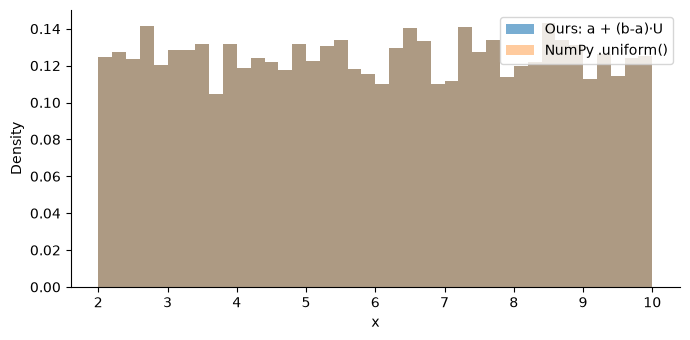

In [5]:
# SOLUTION
def sample_uniform(rng, a, b, n):
    u = rng.random(n)
    return a + (b - a) * u


# --- Validation ---
SEED = 0
rng_ours = np.random.default_rng(SEED)   # same seed
rng_ref  = np.random.default_rng(SEED)   # same seed

x_ours  = sample_uniform(rng_ours, a=2, b=10, n=10_000)
x_numpy = rng_ref.uniform(2, 10, 10_000)

# Same seed + correct transformation → numbers should match exactly
print('All values identical?', np.allclose(x_ours, x_numpy))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(x_ours,  bins=40, alpha=0.6, color='#1f77b4', density=True, label='Ours: a + (b-a)·U')
ax.hist(x_numpy, bins=40, alpha=0.4, color='#ff7f0e', density=True, label='NumPy .uniform()')
ax.set_xlabel('x'); ax.set_ylabel('Density'); ax.legend()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

### Task B.1 — Weibull

**(a)** Derive $F^{-1}(u)$ on paper.
**(b)** Implement `sample_weibull` and validate.

**Derivation of $F^{-1}(u)$:**

$$1 - \exp\!\left[-\left(\frac{x}{\lambda}\right)^k\right] = u$$
$$\exp\!\left[-\left(\frac{x}{\lambda}\right)^k\right] = 1 - u$$
$$\left(\frac{x}{\lambda}\right)^k = -\ln(1 - u)$$
$$\boxed{\,X = \lambda \cdot \bigl[-\ln(1 - U)\bigr]^{1/k}\,}$$

All values identical? False


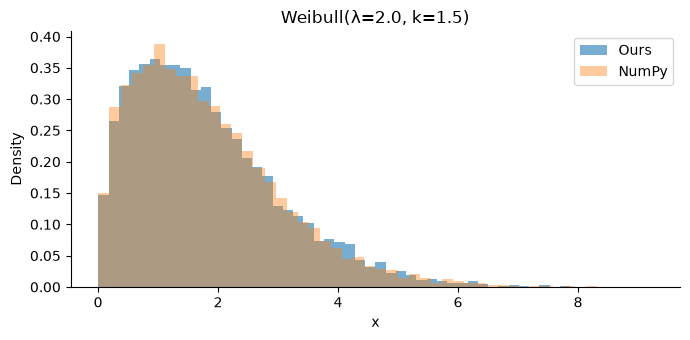

In [6]:
# SOLUTION
def sample_weibull(rng, lam, k, n):
    u = rng.random(n)
    return lam * (-np.log(1 - u)) ** (1 / k)


# --- Validation ---
SEED = 1
rng_ours = np.random.default_rng(SEED)   # same seed
rng_ref  = np.random.default_rng(SEED)   # same seed

lam, k = 2.0, 1.5
x_ours  = sample_weibull(rng_ours, lam, k, 10_000)
x_numpy = rng_ref.weibull(k, 10_000) * lam

print('All values identical?', np.allclose(x_ours, x_numpy))
# Note: this returns False even though our implementation is mathematically correct.
# NumPy's rng.weibull() uses the Ziggurat algorithm internally — a rejection-based
# method that consumes a *variable* number of uniform draws per Weibull sample. So even
# with the same seed, the uniform stream is consumed differently and the per-sample
# values diverge. The distributions still agree (see histogram below), which is the
# correct validation criterion when comparing inverse transform against a reference
# implementation that uses a different algorithm.

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(x_ours,  bins=50, alpha=0.6, color='#1f77b4', density=True, label='Ours')
ax.hist(x_numpy, bins=50, alpha=0.4, color='#ff7f0e', density=True, label='NumPy')
ax.set_xlabel('x'); ax.set_ylabel('Density'); ax.legend()
ax.set_title(f'Weibull(λ={lam}, k={k})')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

### Task B.2 — Triangular $(a, b, c)$

The **Triangular** distribution on $[a, b]$ with mode $c$ has CDF

$$F(x) = \begin{cases} \dfrac{(x - a)^2}{(b - a)(c - a)} & a \leq x \leq c \\[8pt] 1 - \dfrac{(b - x)^2}{(b - a)(b - c)} & c < x \leq b \end{cases}$$

**(a)** Derive the piecewise inverse $F^{-1}(u)$ on paper.

**(b)** Implement `sample_triangular(rng, a, b, c, n)` and validate against `rng.triangular(a, c, b, n)` (note NumPy's argument order is *left, mode, right*).

**Derivation of $F^{-1}(u)$ for Triangular $(a, b, c)$:**

The threshold is $u^{\star} = F(c) = (c - a) / (b - a)$.

**Left branch** ($u \leq u^{\star}$):

$$\frac{(X - a)^2}{(b - a)(c - a)} = U \;\Longrightarrow\; X = a + \sqrt{U \cdot (b - a)(c - a)}$$

**Right branch** ($u > u^{\star}$):

$$1 - \frac{(b - X)^2}{(b - a)(b - c)} = U \;\Longrightarrow\; X = b - \sqrt{(1 - U) \cdot (b - a)(b - c)}$$

All values identical? True


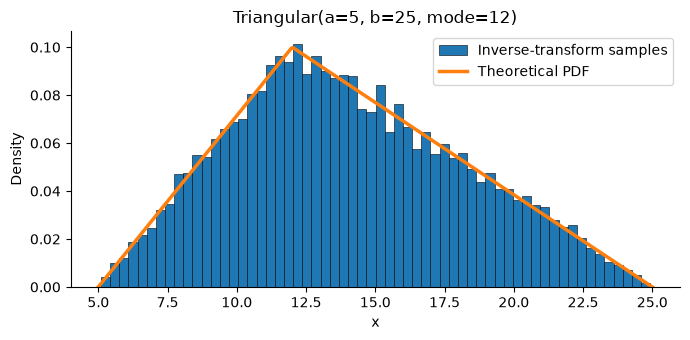

In [7]:
# SOLUTION
def sample_triangular(rng, a, b, c, n):
    u = rng.random(n)
    threshold = (c - a) / (b - a)               # F(c)
    return np.where(u <= threshold,
                    a + np.sqrt(u * (b - a) * (c - a)),
                    b - np.sqrt((1 - u) * (b - a) * (b - c)))


# --- Validation ---
SEED = 2
rng_ours = np.random.default_rng(SEED)   # same seed
rng_ref  = np.random.default_rng(SEED)   # same seed

a, b, c = 5, 25, 12
x_ours  = sample_triangular(rng_ours, a, b, c, 20_000)
x_numpy = rng_ref.triangular(a, c, b, 20_000)

print('All values identical?', np.allclose(x_ours, x_numpy))

x_grid = np.linspace(a, b, 400)
pdf = np.where(x_grid <= c,
               2 * (x_grid - a) / ((b - a) * (c - a)),
               2 * (b - x_grid) / ((b - a) * (b - c)))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(x_ours, bins=60, color='#1f77b4', edgecolor='black', linewidth=0.4,
        density=True, label='Inverse-transform samples')
ax.plot(x_grid, pdf, color='#ff7f0e', linewidth=2.5, label='Theoretical PDF')
ax.set_xlabel('x'); ax.set_ylabel('Density'); ax.legend()
ax.set_title(f'Triangular(a={a}, b={b}, mode={c})')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

---
## Part C — Convolution: Erlang from Exponentials

Some distributions can be obtained simply by **summing** independent samples from a simpler one — no inverse transform, no rejection. The **Erlang $(k, \lambda)$** distribution is the sum of $k$ independent $\text{Exp}(\lambda)$ variates.

Implement `sample_erlang(rng, k, lam, n)` and validate against `scipy.stats.erlang.rvs`.

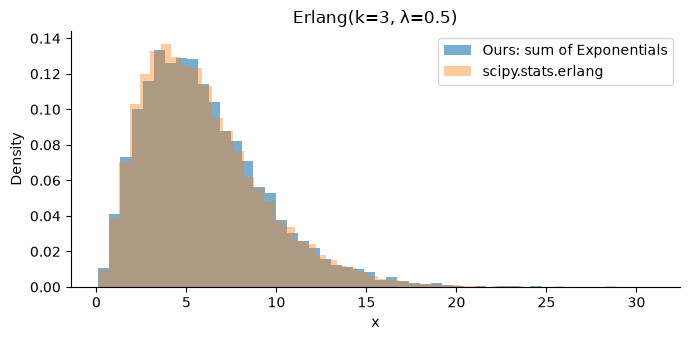

In [8]:
# SOLUTION
def sample_erlang(rng, k, lam, n):
    # For each of n requested samples, sum k independent Exp(lam) draws.
    samples = np.empty(n)
    for i in range(n):
        total = 0.0
        for _ in range(k):
            total += rng.exponential(scale=1 / lam)   # one Exp(lam) draw
        samples[i] = total
    return samples


rng = np.random.default_rng(3)
k, lam = 3, 0.5
x_ours = sample_erlang(rng, k, lam, 10_000)
x_scipy = stats.erlang.rvs(k, scale=1/lam, size=10_000, random_state=3)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(x_ours,  bins=50, alpha=0.6, color='#1f77b4', density=True, label='Ours: sum of Exponentials')
ax.hist(x_scipy, bins=50, alpha=0.4, color='#ff7f0e', density=True, label='scipy.stats.erlang')
ax.set_xlabel('x'); ax.set_ylabel('Density'); ax.legend()
ax.set_title(f'Erlang(k={k}, λ={lam})')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

**Why don't `ours` and `scipy` produce identical samples?**

Even with the same nominal seed, our implementation and `scipy.stats.erlang.rvs` consume the underlying random stream differently:

- Ours draws **$k$ independent Exponentials** (each via `rng.exponential`, which itself uses the Ziggurat algorithm — a rejection method whose number of uniform draws per output varies).
- `scipy.stats.erlang.rvs` calls into a different generator routine entirely, with its own stream-consumption pattern.

The **distributions agree** (the histograms overlap) — that is the correct validation. Per-sample byte equality is not expected when comparing against a reference that uses a different algorithm.

---
## Part D — Acceptance-Rejection

When a CDF cannot be inverted in closed form, the **acceptance-rejection** method is a versatile alternative.

**Dart-throwing analogy.** Imagine the target PDF $f(x)$ drawn on a sheet of paper. Draw a flat rectangle of height $h \geq \max_x f(x)$ that completely covers the curve. Throw uniform darts into the rectangle. The darts that land *under* the curve $f$ are **accepted**: their $x$-coordinates follow the target distribution $f$. The darts that land *above* the curve are **rejected**.

We will sample from the **Beta $(2, 5)$** distribution this way. Its PDF on $[0, 1]$ is

$$f(x) = \frac{1}{B(2, 5)} \, x \, (1 - x)^4 \quad\text{with }\, B(2, 5) = \frac{1!\,4!}{6!} = \frac{1}{30}, \quad\text{so}\quad f(x) = 30 \, x \, (1 - x)^4.$$

**Algorithm (from the lecture).** To sample from a PDF $f(x)$ on a bounded interval $[a, b]$:

1. Find a height $h$ that bounds $f$ from above: $f(x) \leq h$ for all $x \in [a, b]$. The simplest choice is $h = \max_x f(x)$.
2. Sample a candidate $X \sim \text{Uniform}(a, b)$ and an independent height $Y \sim \text{Uniform}(0, h)$.
3. **Accept the candidate $X$** if $Y \leq f(X)$. Otherwise **reject** and try again.

**Tasks**:

**(a)** Compute $h = \max_x f(x)$ analytically (or numerically).

**(b)** Implement `sample_beta_25_ar(rng, n)` returning **two arrays of $(x, y)$ darts**: the **accepted** ones (length $n$) and all the **rejected** ones encountered along the way. Report the empirical acceptance rate.

**(c)** Plot two panels: **(left)** all darts coloured by accept/reject with the PDF and envelope overlaid — this should visually show accepted darts forming the area *under* $f$ and rejected darts filling the area *above*; **(right)** a histogram of the accepted $x$-values against the theoretical PDF as a distribution check.

Envelope height h = f(0.2) = 2.458
Empirical acceptance rate: 41.52%


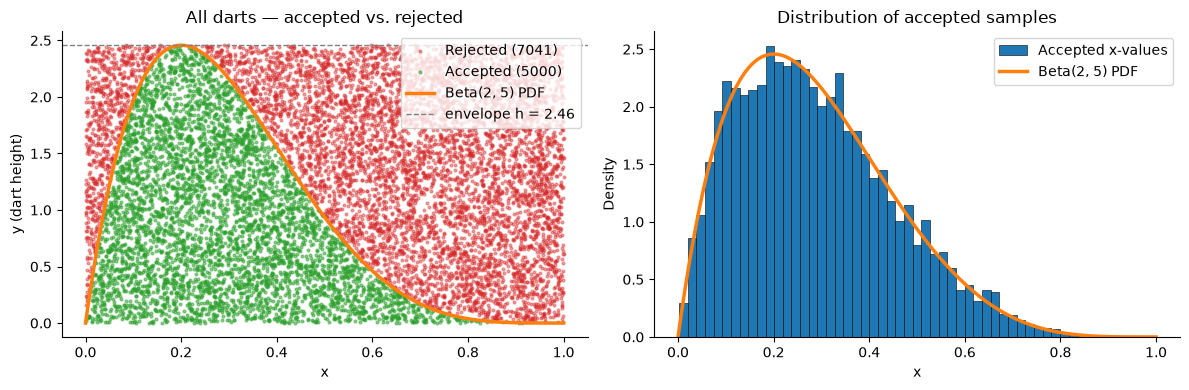

In [9]:
# SOLUTION
def f(x):
    return 30 * x * (1 - x) ** 4

# (a) The maximum of f on [0, 1]: differentiate and set to 0.
# f'(x) = 30 (1-x)^3 (1 - 5x) = 0  →  x* = 1/5
x_star = 1 / 5
h = f(x_star)
print(f'Envelope height h = f({x_star}) = {h:.3f}')


def sample_beta_25_ar(rng, n):
    accepted = []
    rejected = []
    while len(accepted) < n:
        x = rng.uniform(0, 1)
        y = rng.uniform(0, h)
        if y <= f(x):
            accepted.append((x, y))
        else:
            rejected.append((x, y))
    return np.array(accepted), np.array(rejected)


# --- Validation & visualization ---
rng = np.random.default_rng(4)
accepted, rejected = sample_beta_25_ar(rng, 5_000)
n_total = len(accepted) + len(rejected)
print(f'Empirical acceptance rate: {len(accepted) / n_total:.2%}')

x_grid = np.linspace(0, 1, 400)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(rejected[:, 0], rejected[:, 1], s=4, color='#d62728', alpha=0.4,
                label=f'Rejected ({len(rejected)})')
axes[0].scatter(accepted[:, 0], accepted[:, 1], s=4, color='#2ca02c', alpha=0.5,
                label=f'Accepted ({len(accepted)})')
axes[0].plot(x_grid, f(x_grid), color='#ff7f0e', linewidth=2.5, label='Beta(2, 5) PDF')
axes[0].axhline(h, color='gray', linestyle='--', linewidth=1, label=f'envelope h = {h:.2f}')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y (dart height)')
axes[0].set_title('All darts — accepted vs. rejected'); axes[0].legend()
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

axes[1].hist(accepted[:, 0], bins=50, color='#1f77b4', edgecolor='black', linewidth=0.4,
             density=True, label='Accepted x-values')
axes[1].plot(x_grid, f(x_grid), color='#ff7f0e', linewidth=2.5, label='Beta(2, 5) PDF')
axes[1].set_xlabel('x'); axes[1].set_ylabel('Density')
axes[1].set_title('Distribution of accepted samples'); axes[1].legend()
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout(); plt.show()

# Acceptance rate ≈ 1/h ≈ 41% (= area under f / area of envelope rectangle)

---
## Part E — Common Random Numbers (CRN)

We compare 1 vs 2 cashiers. The choice of seeds determines whether the comparison is fair.

In [10]:
# Provided — Mensa model (modeling conventions)
class Mensa:
    def __init__(self, env, num_cashiers, mean_service, svc_rng):
        self.env = env
        self.counter = simpy.Resource(env, capacity=num_cashiers)
        self.mean_service = mean_service
        self.svc_rng = svc_rng

    def serve(self):
        yield self.env.timeout(self.svc_rng.exponential(self.mean_service))


class Student:
    def __init__(self, env, name, mensa, waits):
        self.env = env; self.name = name; self.mensa = mensa; self.waits = waits

    def run(self):
        arrive = self.env.now
        with self.mensa.counter.request() as req:
            yield req
            self.waits.append(self.env.now - arrive)
            yield self.env.process(self.mensa.serve())


def student_generator(env, mensa, waits, mean_inter, arr_rng):
    i = 0
    while True:
        yield env.timeout(arr_rng.exponential(mean_inter))
        env.process(Student(env, f'S{i}', mensa, waits).run())
        i += 1


def simulate_mensa(num_cashiers, arr_seed, svc_seed,
                     mean_interarrival=1.0, mean_service=1.5, sim_time=20):
    arr_rng = np.random.default_rng(arr_seed)
    svc_rng = np.random.default_rng(svc_seed)
    env = simpy.Environment()
    mensa = Mensa(env, num_cashiers=num_cashiers,
                  mean_service=mean_service, svc_rng=svc_rng)
    waits = []
    env.process(student_generator(env, mensa, waits, mean_interarrival, arr_rng))
    env.run(until=sim_time)
    return np.mean(waits) if waits else 0.0

### Task E.1 — Naive comparison (different seeds)

In [11]:
# SOLUTION
# Different seeds for the two designs — naive comparison
w1 = simulate_mensa(num_cashiers=1, arr_seed=0, svc_seed=0)
w2 = simulate_mensa(num_cashiers=2, arr_seed=1, svc_seed=1)
print(f'1 cashier  (seed 0): avg wait = {w1:.2f} min')
print(f'2 cashiers (seed 1): avg wait = {w2:.2f} min')
print(f'"Improvement":             {w1 - w2:+.2f} min  ← 2 cashiers may even look WORSE!')

# With short runs and different seeds, the measured difference fluctuates wildly.
# In this seed pair 2 cashiers actually appear worse — pure randomness, not the design.

1 cashier  (seed 0): avg wait = 0.89 min
2 cashiers (seed 1): avg wait = 1.40 min
"Improvement":             -0.51 min  ← 2 cashiers may even look WORSE!


### Task E.2 — CRN comparison (same seeds)

In [12]:
# SOLUTION
# CRN: same seeds for both designs
w1 = simulate_mensa(num_cashiers=1, arr_seed=0, svc_seed=0)
w2 = simulate_mensa(num_cashiers=2, arr_seed=0, svc_seed=0)
print(f'1 cashier  (seed 0): avg wait = {w1:.2f} min')
print(f'2 cashiers (seed 0): avg wait = {w2:.2f} min')
print(f'Improvement:               {w1 - w2:+.2f} min  ← 2 cashiers correctly look better')

1 cashier  (seed 0): avg wait = 0.89 min
2 cashiers (seed 0): avg wait = 0.03 min
Improvement:               +0.87 min  ← 2 cashiers correctly look better


**Interpretation:** With CRN, both designs face the **identical** sequence of arrivals and service times. Any remaining difference reflects the design choice (cashier capacity), not random variation. 2 cashiers consistently outperform 1, as queueing theory predicts.

---

### A subtle question: don't 2 cashiers consume more random numbers than 1?

Yes — the 2-cashier system serves more students within the simulation horizon, so it draws more service-time random numbers. So how can we say the comparison is *fair* under CRN?

**The key is the structure of the model.** Service times are drawn from a *dedicated* `svc_rng` only when a student starts being served:

```python
def serve(self):
    yield self.env.timeout(self.svc_rng.exponential(self.mean_service))
```

Both with 1 and 2 cashiers, students start service in **arrival order** (SimPy's `Resource` is FIFO by default — the second cashier just enables a second service to start in parallel; it does not reorder anyone).

This means the matchup of draws looks like:

| | 1 cashier | 2 cashiers |
|---|---|---|
| Student 0's service time | `svc_rng` draw #0 | `svc_rng` draw #0 |
| Student 1's service time | `svc_rng` draw #1 | `svc_rng` draw #1 |
| ... | ... | ... |
| Student $N_1$'s service time | `svc_rng` draw #$N_1$ | `svc_rng` draw #$N_1$ |
| Student $N_1 + 1$'s service time | (queue stuck — never drawn) | `svc_rng` draw #$N_1 + 1$ |
| ... | | continues for more students |

So **the first $N_1$ service times are identical** between the two simulations. The 2-cashier sim just continues drawing further into the stream because more students reach the counter within the time window. The unpaired tail is *additional* information that the 1-cashier sim couldn't provide (because those students never got served).

**Why CRN works here:**

1. **Separate streams per source.** `arr_rng` and `svc_rng` are isolated. The 2-cashier system consuming more service draws does not shift any arrival times.
2. **Same order of consumption within each stream.** Student $i$ always gets the $i$-th service time draw, regardless of capacity.

Each *paired* student faces the same arrival time *and* the same service time in both designs. Any difference in waiting time is therefore attributable to the **capacity** difference — exactly what we want to measure.

**When CRN breaks**

- **If we mixed streams.** A single global RNG for both arrivals and services would mean the extra service draw in the 2-cashier case shifts the next arrival — streams would diverge.
- **If the queueing discipline reordered students.** Shortest-job-first, for example, would let a later-arriving student with a short service time be served before an earlier one. Then student $i$ no longer gets the $i$-th draw, and the matchup is broken even with separate streams.

The textbook CRN recipe — **one independent stream per source of randomness, FIFO discipline** — sidesteps both pitfalls.

---
## Short Questions

*The following questions are comparable to exam questions in format and expected answer length. Note that content-wise they are on the harder end — use them to stress-test your understanding.*

**Q1** — Why is the consecutive-pair scatter plot $(X_n, X_{n+1})$ a more sensitive diagnostic of RNG quality than a 1-D histogram of the marginal $\{X_n\}$?

**Answer:** The 1-D histogram only checks **uniformity** of single samples. The consecutive-pair scatter additionally probes **independence**: if successive samples are correlated, the pairs cluster onto lines or lattice patterns even when each marginal looks perfectly uniform. So the 2-D scatter detects a failure mode (dependence) that the 1-D histogram is blind to.

**Q2** — The Cauchy distribution with location $\mu$ and scale $\gamma$ has CDF

$$F(x) = \frac{1}{\pi} \arctan\!\left(\frac{x - \mu}{\gamma}\right) + \frac{1}{2}.$$

Derive the inverse-transform sampler $X = F^{-1}(U)$.

*(Bonus, beyond the lecture scope — see the solution note below: what is unusual about the Cauchy distribution that makes inverse transform especially convenient here?)*

**Answer:** Solve $F(X) = U$:

$$\frac{1}{\pi} \arctan\!\left(\frac{X - \mu}{\gamma}\right) + \frac{1}{2} = U$$

$$\arctan\!\left(\frac{X - \mu}{\gamma}\right) = \pi (U - 1/2)$$

$$\boxed{X = \mu + \gamma \cdot \tan\!\bigl(\pi (U - 1/2)\bigr)}$$

---

**Bonus answer (beyond the lecture scope — students aren't expected to know this on their own):**

The Cauchy distribution has **no finite mean and no finite variance** — the integrals defining them diverge because of its very heavy tails. Yet inverse transform doesn't care about moments: it only requires the CDF to be invertible in closed form, which Cauchy provides. The Normal, by contrast, is well-behaved (finite moments) but its CDF $\Phi$ has no closed-form inverse, so inverse transform is impractical and one must use Box-Muller or numerical inversion.

*Take-away*: invertibility of the CDF and the existence of moments are independent properties — having the latter doesn't help inverse transform, and lacking it doesn't hurt.

**Q3** — A colleague claims: *"I seeded `random.seed(42)` for both my alternative simulations, so my comparison is automatically valid by CRN."* Critique this claim — list **at least three** ways their comparison can still be unfair, and suggest a fix for each.

**Answer:** Three pitfalls (any three of):

1. **Single shared stream.** If both designs share one global `random` stream, any structural difference between them (extra random call, different decision branch) shifts the stream and they no longer face the same noise. *Fix:* allocate a separate `default_rng` per noise source.
2. **Different number of consumed draws per logical event.** E.g. design B uses A/R for one of its samplers and rejects more draws. Even within a 'source', the streams diverge. *Fix:* use only inverse-transform-style samplers (one draw per output) within each shared stream, or maintain a per-event sub-stream.
3. **Non-FIFO queueing discipline.** Priority queues, shortest-job-first, etc. reorder which entity consumes which random draw. *Fix:* stick to FIFO during the comparison; or allocate per-entity sub-streams indexed by entity ID.
4. **Mixing `random` and `np.random`.** These are independent streams; seeding only one doesn't seed the other. *Fix:* seed both, or use `default_rng` exclusively.
5. **Insufficient replications.** Even with CRN, a single run gives a noisy point estimate. *Fix:* run multiple seed pairs and report a paired confidence interval on the difference.

**Q4** — For acceptance-rejection with a uniform envelope giving acceptance rate $p$, what is the expected number of trials per accepted sample? Justify by identifying the underlying distribution.

**Answer:** Each trial is a **Bernoulli** with success probability $p$ (success = "accepted"). The number of trials until the first acceptance is therefore **geometric** with parameter $p$, with expected value

$$E[\text{trials}] = \frac{1}{p}.$$

So if $p = 0.4$, you expect $1/0.4 = 2.5$ trials per accepted sample on average. In the limit of a poor envelope ($p \to 0$), the expected work per sample diverges — confirming why envelope choice matters.